# 02 - Model Inference, Comparison & Export

This notebook demonstrates:
1. **Model Inference**: Running predictions on sample images from the holdout set
2. **Visualization**: Showing model predictions with confidence scores
3. **Challenging Cases**: Identifying images where models struggle
4. **Teacher vs Student Comparison**: Finding cases where teacher succeeds but student fails
5. **Model Export**: Saving models to ONNX and TorchScript formats for deployment

## Setup

In [19]:
import sys
import pathlib
from pathlib import Path

# Add project root to path
PROJECT_ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

from src.config import (
    CHECKPOINTS_DIR, PROCESSED_DIR, MODELS_DIR, 
    TeacherConfig, StudentConfig, DataConfig, get_device, set_seed
)
from src.models.architectures import TeacherModel, StudentModel
from src.data.dataset import HAM10000Dataset, get_eval_transforms

# Set random seed for reproducibility
set_seed(42)

# Get device
DEVICE = get_device()
print(f"Using device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")

Using device: mps
Project root: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project
Checkpoints dir: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project/models/checkpoints


## 1. Load Best Teacher and Student Models

Based on evaluation results, we'll load:
- **Best Teacher**: EfficientNet-B1 (highest ROC-AUC: 0.919)
- **Best Student**: MobileNetV3-Small with T=2.0, α=0.9

In [20]:
def load_model(model_class, config, checkpoint_path, device):
    """Load a model from checkpoint."""
    model = model_class(config)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    if isinstance(checkpoint, dict):
        if "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
        elif "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"])
        else:
            model.load_state_dict(checkpoint)
    else:
        model.load_state_dict(checkpoint)
    
    model = model.to(device)
    model.eval()
    return model


# Load best teacher (EfficientNet-B1)
teacher_config = TeacherConfig(architecture="efficientnet_b1")
teacher_checkpoint = CHECKPOINTS_DIR / "teacher_efficientnet_b1_focal_best.pth"
teacher_model = load_model(TeacherModel, teacher_config, teacher_checkpoint, DEVICE)
print(f"✓ Loaded Teacher: EfficientNet-B1 ({teacher_model.count_parameters()['total']:,} params)")

# Load best student (T=2.0, alpha=0.9)
student_config = StudentConfig()
student_checkpoint = CHECKPOINTS_DIR / "student_T2.0_alpha0.9_best.pth"
student_model = load_model(StudentModel, student_config, student_checkpoint, DEVICE)
print(f"✓ Loaded Student: MobileNetV3-Small ({student_model.count_parameters()['total']:,} params)")
print(f"  Student size: {student_model.get_model_size_mb():.2f} MB")

✓ Loaded Teacher: EfficientNet-B1 (6,514,465 params)
✓ Loaded Student: MobileNetV3-Small (1,518,881 params)
  Student size: 5.84 MB


## 2. Load Holdout Dataset

In [21]:
# Load holdout data
holdout_csv = PROCESSED_DIR / "holdout_data.csv"
holdout_df = pd.read_csv(holdout_csv)

# Create dataset with eval transforms
data_config = DataConfig()
eval_transforms = get_eval_transforms(data_config)
holdout_dataset = HAM10000Dataset(holdout_csv, transform=eval_transforms, config=data_config)

print(f"Holdout set: {len(holdout_dataset)} samples")
print(f"  Melanoma (positive): {holdout_dataset.num_positive}")
print(f"  Non-melanoma (negative): {holdout_dataset.num_negative}")
print(f"  Prevalence: {holdout_dataset.prevalence:.2%}")

# Display class distribution
holdout_df['lesion_type'].value_counts()

Holdout set: 1513 samples
  Melanoma (positive): 172
  Non-melanoma (negative): 1341
  Prevalence: 11.37%


lesion_type
Melanocytic nevi                 1008
Benign keratosis-like lesions     174
Melanoma                          172
Basal cell carcinoma               76
Actinic keratoses                  49
Vascular lesions                   20
Dermatofibroma                     14
Name: count, dtype: int64

## 3. Helper Functions for Visualization

In [22]:
def get_prediction(model, image_tensor, device):
    """Get model prediction and probability."""
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logit = model(image_tensor)
        prob = torch.sigmoid(logit).item()
        pred = int(prob > 0.5)
    return pred, prob


def load_original_image(image_path):
    """Load original image without transforms."""
    return Image.open(image_path).convert("RGB")


def plot_prediction(image, true_label, teacher_pred, teacher_prob, 
                   student_pred, student_prob, title="", ax=None):
    """Plot image with prediction results."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.imshow(image)
    ax.axis('off')
    
    # True label
    true_label_str = "MELANOMA" if true_label == 1 else "BENIGN"
    true_color = "red" if true_label == 1 else "green"
    
    # Teacher prediction
    teacher_correct = "✓" if teacher_pred == true_label else "✗"
    teacher_color = "green" if teacher_pred == true_label else "red"
    
    # Student prediction
    student_correct = "✓" if student_pred == true_label else "✗"
    student_color = "green" if student_pred == true_label else "red"
    
    ax.set_title(f"{title}\n" if title else "")
    
    # Add text annotations
    text = f"Ground Truth: {true_label_str}\n"
    text += f"Teacher: {teacher_prob:.1%} {teacher_correct}\n"
    text += f"Student: {student_prob:.1%} {student_correct}"
    
    ax.text(0.02, 0.02, text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Color border based on ground truth
    for spine in ax.spines.values():
        spine.set_edgecolor(true_color)
        spine.set_linewidth(3)
        spine.set_visible(True)


def get_all_predictions(teacher_model, student_model, dataset, device):
    """Get predictions for all samples in dataset."""
    results = []
    
    for idx in range(len(dataset)):
        image_tensor, true_label = dataset[idx]
        
        teacher_pred, teacher_prob = get_prediction(teacher_model, image_tensor, device)
        student_pred, student_prob = get_prediction(student_model, image_tensor, device)
        
        results.append({
            'idx': idx,
            'true_label': true_label,
            'teacher_pred': teacher_pred,
            'teacher_prob': teacher_prob,
            'student_pred': student_pred,
            'student_prob': student_prob,
            'teacher_correct': teacher_pred == true_label,
            'student_correct': student_pred == true_label,
            'image_path': dataset.df.iloc[idx]['image_path'],
            'lesion_type': dataset.df.iloc[idx]['lesion_type'],
            'dx': dataset.df.iloc[idx]['dx'],
        })
    
    return pd.DataFrame(results)


print("Helper functions defined.")

Helper functions defined.


## 4. Run Inference on Holdout Set

In [23]:
# Get predictions for all holdout samples
print("Running inference on holdout set...")
predictions_df = get_all_predictions(teacher_model, student_model, holdout_dataset, DEVICE)

# Summary statistics
teacher_acc = predictions_df['teacher_correct'].mean()
student_acc = predictions_df['student_correct'].mean()

print(f"\n=== Holdout Set Performance ===")
print(f"Teacher Accuracy: {teacher_acc:.2%}")
print(f"Student Accuracy: {student_acc:.2%}")
print(f"\nConfusion Analysis:")
print(f"  Both correct: {((predictions_df['teacher_correct']) & (predictions_df['student_correct'])).sum()}")
print(f"  Both wrong: {((~predictions_df['teacher_correct']) & (~predictions_df['student_correct'])).sum()}")
print(f"  Teacher only correct: {((predictions_df['teacher_correct']) & (~predictions_df['student_correct'])).sum()}")
print(f"  Student only correct: {((~predictions_df['teacher_correct']) & (predictions_df['student_correct'])).sum()}")

Running inference on holdout set...

=== Holdout Set Performance ===
Teacher Accuracy: 86.38%
Student Accuracy: 85.46%

Confusion Analysis:
  Both correct: 1207
  Both wrong: 120
  Teacher only correct: 100
  Student only correct: 86


## 5. Visualize Sample Predictions

### 5.1 Correct Predictions (Easy Cases)

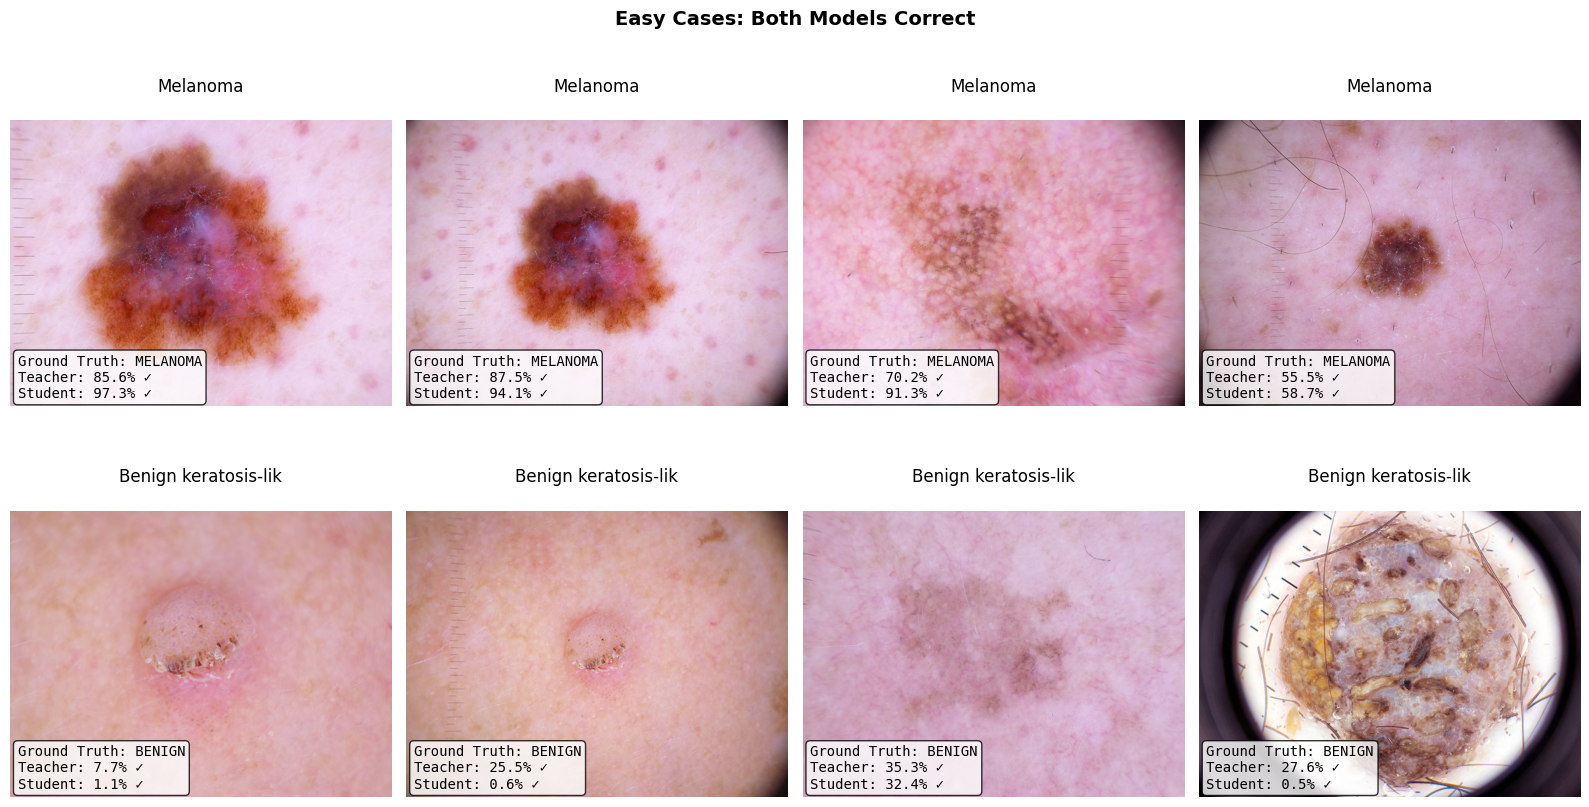

In [24]:
# Find cases where both models are correct
both_correct = predictions_df[
    (predictions_df['teacher_correct']) & 
    (predictions_df['student_correct'])
]

# Sample some from each class
melanoma_correct = both_correct[both_correct['true_label'] == 1].head(4)
benign_correct = both_correct[both_correct['true_label'] == 0].head(4)
samples = pd.concat([melanoma_correct, benign_correct])

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    image = load_original_image(row['image_path'])
    plot_prediction(
        image, row['true_label'],
        row['teacher_pred'], row['teacher_prob'],
        row['student_pred'], row['student_prob'],
        title=f"{row['lesion_type'][:20]}",
        ax=axes[i]
    )

plt.suptitle("Easy Cases: Both Models Correct", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "artifacts" / "imgs" / "02_inference" / "easy_cases.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Challenging Cases (Both Models Wrong)

Found 120 challenging cases where both models failed.


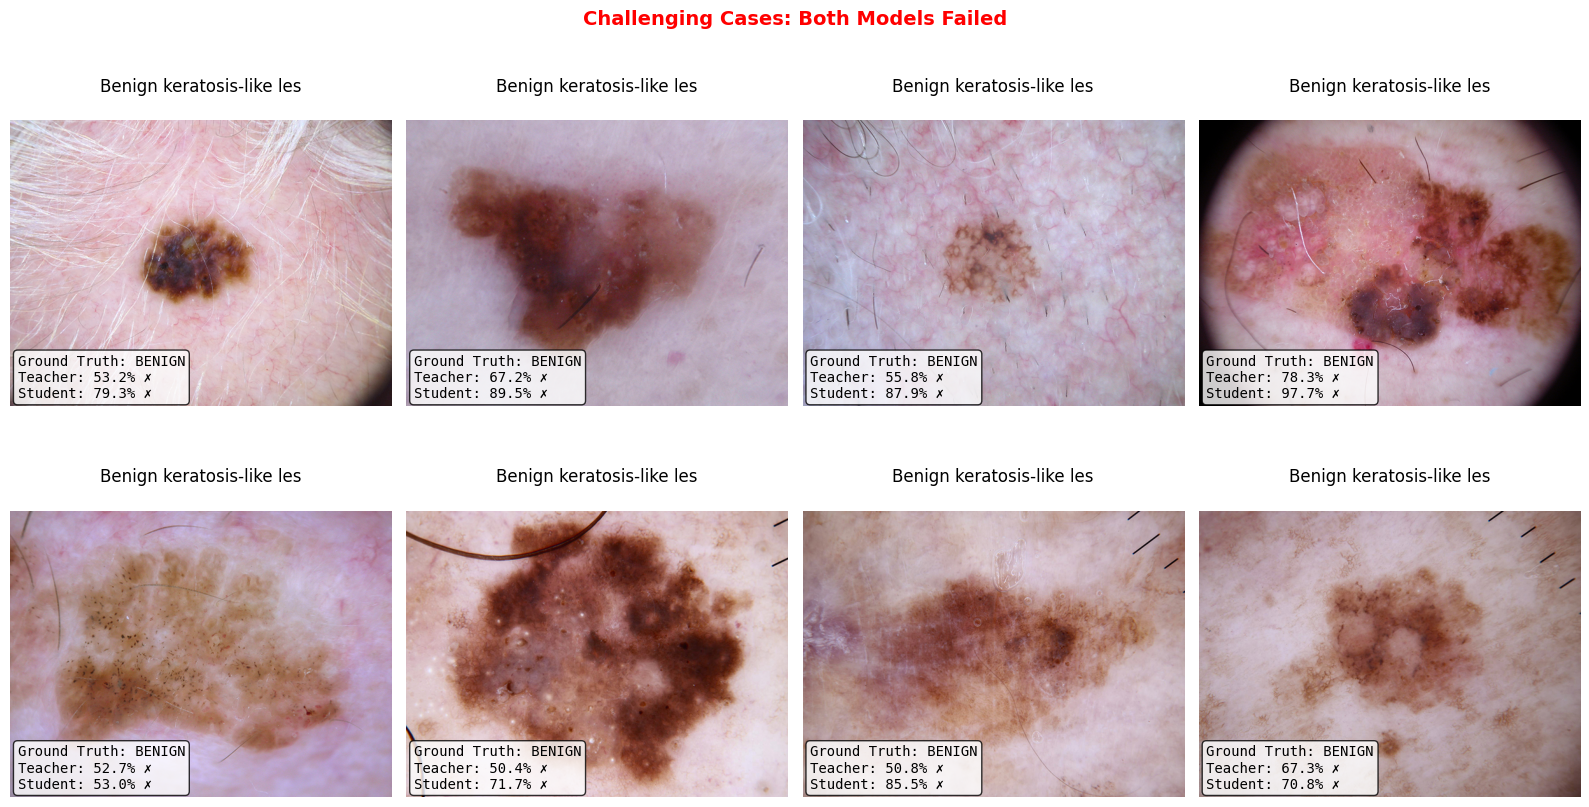

In [25]:
# Create output directory
output_dir = PROJECT_ROOT / "artifacts" / "imgs" / "02_inference"
output_dir.mkdir(parents=True, exist_ok=True)

# Find cases where both models are wrong
both_wrong = predictions_df[
    (~predictions_df['teacher_correct']) & 
    (~predictions_df['student_correct'])
]

print(f"Found {len(both_wrong)} challenging cases where both models failed.")

# Show some challenging cases
n_samples = min(8, len(both_wrong))
if n_samples > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(both_wrong.head(n_samples).iterrows()):
        image = load_original_image(row['image_path'])
        plot_prediction(
            image, row['true_label'],
            row['teacher_pred'], row['teacher_prob'],
            row['student_pred'], row['student_prob'],
            title=f"{row['lesion_type'][:25]}",
            ax=axes[i]
        )
    
    # Hide empty subplots
    for j in range(n_samples, 8):
        axes[j].axis('off')
    
    plt.suptitle("Challenging Cases: Both Models Failed", fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig(output_dir / "challenging_cases.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No cases where both models failed!")

### 5.3 Knowledge Gap: Teacher Correct, Student Wrong

These cases show where knowledge distillation could be improved - the teacher has learned something the student hasn't captured.

Found 100 cases where teacher succeeds but student fails.

Breakdown by lesion type:
lesion_type
Melanocytic nevi                 42
Benign keratosis-like lesions    26
Actinic keratoses                12
Basal cell carcinoma             11
Melanoma                          7
Dermatofibroma                    1
Vascular lesions                  1
Name: count, dtype: int64


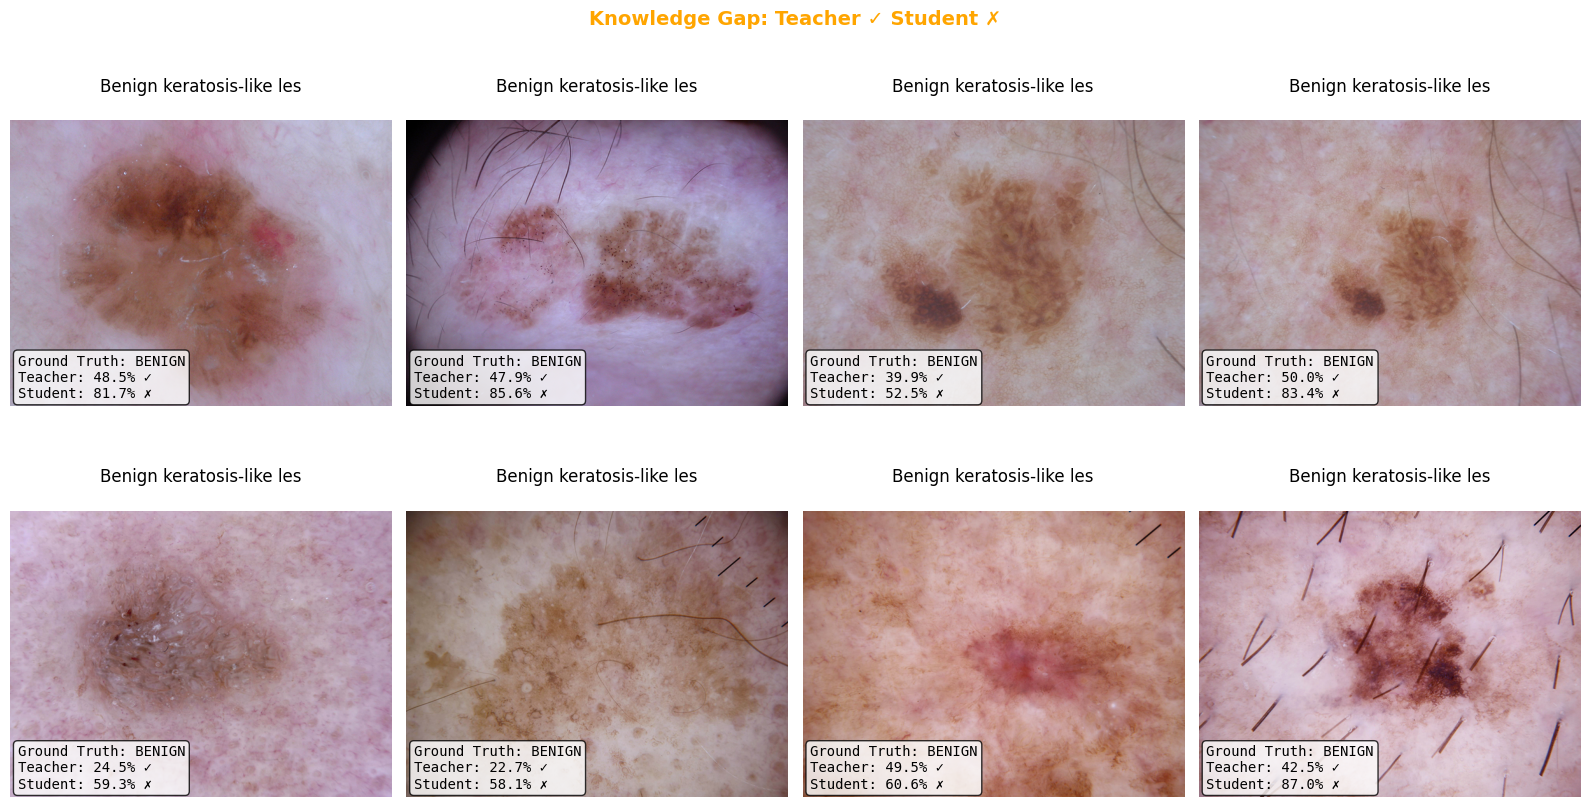

In [26]:
# Find cases where teacher is correct but student is wrong
teacher_only_correct = predictions_df[
    (predictions_df['teacher_correct']) & 
    (~predictions_df['student_correct'])
]

print(f"Found {len(teacher_only_correct)} cases where teacher succeeds but student fails.")
print(f"\nBreakdown by lesion type:")
print(teacher_only_correct['lesion_type'].value_counts())

# Show these important cases
n_samples = min(8, len(teacher_only_correct))
if n_samples > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(teacher_only_correct.head(n_samples).iterrows()):
        image = load_original_image(row['image_path'])
        plot_prediction(
            image, row['true_label'],
            row['teacher_pred'], row['teacher_prob'],
            row['student_pred'], row['student_prob'],
            title=f"{row['lesion_type'][:25]}",
            ax=axes[i]
        )
    
    # Hide empty subplots
    for j in range(n_samples, 8):
        axes[j].axis('off')
    
    plt.suptitle("Knowledge Gap: Teacher ✓ Student ✗", fontsize=14, fontweight='bold', color='orange')
    plt.tight_layout()
    plt.savefig(output_dir / "teacher_vs_student.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No cases where teacher succeeds but student fails!")

### 5.4 Confidence Analysis

Visualize the confidence distributions for correct vs incorrect predictions.

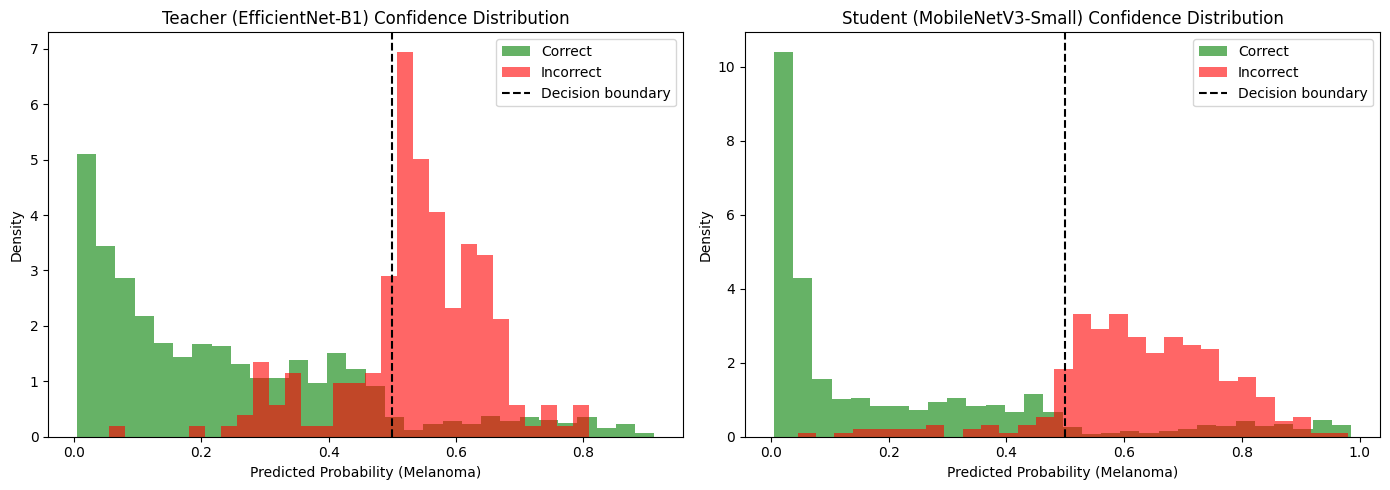

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Teacher confidence distribution
ax = axes[0]
teacher_correct_probs = predictions_df[predictions_df['teacher_correct']]['teacher_prob']
teacher_wrong_probs = predictions_df[~predictions_df['teacher_correct']]['teacher_prob']

ax.hist(teacher_correct_probs, bins=30, alpha=0.6, label='Correct', color='green', density=True)
ax.hist(teacher_wrong_probs, bins=30, alpha=0.6, label='Incorrect', color='red', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
ax.set_xlabel('Predicted Probability (Melanoma)')
ax.set_ylabel('Density')
ax.set_title('Teacher (EfficientNet-B1) Confidence Distribution')
ax.legend()

# Student confidence distribution
ax = axes[1]
student_correct_probs = predictions_df[predictions_df['student_correct']]['student_prob']
student_wrong_probs = predictions_df[~predictions_df['student_correct']]['student_prob']

ax.hist(student_correct_probs, bins=30, alpha=0.6, label='Correct', color='green', density=True)
ax.hist(student_wrong_probs, bins=30, alpha=0.6, label='Incorrect', color='red', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', label='Decision boundary')
ax.set_xlabel('Predicted Probability (Melanoma)')
ax.set_ylabel('Density')
ax.set_title('Student (MobileNetV3-Small) Confidence Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.5 High-Confidence Errors (Most Concerning)

Cases where the model is confidently wrong are the most concerning for deployment.

High-confidence teacher errors: 3


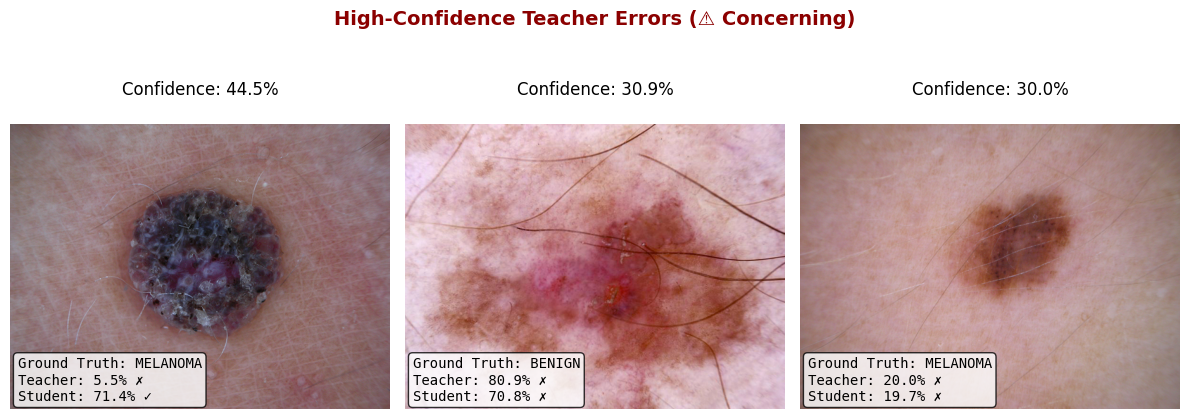

In [10]:
# Find high-confidence errors (probability far from 0.5 but wrong)
predictions_df['teacher_confidence'] = np.abs(predictions_df['teacher_prob'] - 0.5)
predictions_df['student_confidence'] = np.abs(predictions_df['student_prob'] - 0.5)

# High confidence teacher errors
high_conf_teacher_errors = predictions_df[
    (~predictions_df['teacher_correct']) & 
    (predictions_df['teacher_confidence'] > 0.3)
].sort_values('teacher_confidence', ascending=False)

print(f"High-confidence teacher errors: {len(high_conf_teacher_errors)}")

if len(high_conf_teacher_errors) > 0:
    n_samples = min(4, len(high_conf_teacher_errors))
    fig, axes = plt.subplots(1, n_samples, figsize=(4*n_samples, 5))
    if n_samples == 1:
        axes = [axes]
    
    for i, (_, row) in enumerate(high_conf_teacher_errors.head(n_samples).iterrows()):
        image = load_original_image(row['image_path'])
        plot_prediction(
            image, row['true_label'],
            row['teacher_pred'], row['teacher_prob'],
            row['student_pred'], row['student_prob'],
            title=f"Confidence: {row['teacher_confidence']:.1%}",
            ax=axes[i]
        )
    
    plt.suptitle("High-Confidence Teacher Errors (⚠️ Concerning)", fontsize=14, fontweight='bold', color='darkred')
    plt.tight_layout()
    plt.savefig(output_dir / "high_confidence_errors.png", dpi=150, bbox_inches='tight')
    plt.show()

---

## 6. Export Models to ONNX and TorchScript

Export the best models for production deployment:
- **ONNX**: Cross-platform inference (TensorRT, ONNX Runtime, CoreML, etc.)
- **TorchScript**: PyTorch-native deployment (mobile, C++, server)

In [11]:
# Create export directory
EXPORT_DIR = MODELS_DIR / "exported"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Sample input for tracing
data_config = DataConfig()
DUMMY_INPUT = torch.randn(1, 3, data_config.image_size, data_config.image_size).to(DEVICE)

print(f"Export directory: {EXPORT_DIR}")
print(f"Input shape: {DUMMY_INPUT.shape}")

Export directory: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project/models/exported
Input shape: torch.Size([1, 3, 224, 224])


### 6.1 Export to ONNX

In [12]:
def export_to_onnx(model, model_name, dummy_input, export_dir, opset_version=14):
    """Export model to ONNX format."""
    model.eval()
    onnx_path = export_dir / f"{model_name}.onnx"
    
    # Use legacy export (dynamo=False) for broader compatibility
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=opset_version,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
        dynamo=False  # Use legacy export for compatibility
    )
    
    # Get file size
    size_mb = onnx_path.stat().st_size / (1024 ** 2)
    print(f"✓ Exported {model_name} to ONNX: {onnx_path.name} ({size_mb:.2f} MB)")
    return onnx_path


# Export teacher
teacher_onnx = export_to_onnx(teacher_model, "teacher_efficientnet_b1", DUMMY_INPUT, EXPORT_DIR)

# Export student
student_onnx = export_to_onnx(student_model, "student_mobilenetv3_small", DUMMY_INPUT, EXPORT_DIR)

✓ Exported teacher_efficientnet_b1 to ONNX: teacher_efficientnet_b1.onnx (24.84 MB)
✓ Exported student_mobilenetv3_small to ONNX: student_mobilenetv3_small.onnx (5.81 MB)


### 6.2 Validate ONNX Models

In [13]:
import onnx
import onnxruntime as ort

def validate_onnx(onnx_path, pytorch_model, dummy_input):
    """Validate ONNX model matches PyTorch output."""
    # Check ONNX model
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    
    # Run ONNX inference
    ort_session = ort.InferenceSession(str(onnx_path))
    onnx_input = {ort_session.get_inputs()[0].name: dummy_input.cpu().numpy()}
    onnx_output = ort_session.run(None, onnx_input)[0]
    
    # Run PyTorch inference
    pytorch_model.eval()
    with torch.no_grad():
        pytorch_output = pytorch_model(dummy_input).cpu().numpy()
    
    # Compare outputs
    diff = np.abs(onnx_output - pytorch_output).max()
    print(f"✓ {onnx_path.name}: Max difference = {diff:.2e} (should be < 1e-5)")
    return diff < 1e-4


# Validate both models
validate_onnx(teacher_onnx, teacher_model, DUMMY_INPUT)
validate_onnx(student_onnx, student_model, DUMMY_INPUT)

✓ teacher_efficientnet_b1.onnx: Max difference = 3.10e-06 (should be < 1e-5)
✓ student_mobilenetv3_small.onnx: Max difference = 1.91e-06 (should be < 1e-5)


np.True_

### 6.3 Export to TorchScript

In [14]:
def export_to_torchscript(model, model_name, dummy_input, export_dir, method='trace'):
    """Export model to TorchScript format.
    
    Args:
        method: 'trace' or 'script'
            - trace: Records operations during forward pass (faster, less flexible)
            - script: Analyzes Python code (handles control flow)
    """
    model.eval()
    ts_path = export_dir / f"{model_name}.pt"
    
    with torch.no_grad():
        if method == 'trace':
            traced_model = torch.jit.trace(model, dummy_input)
        else:
            traced_model = torch.jit.script(model)
    
    # Optimize for inference
    traced_model = torch.jit.optimize_for_inference(traced_model)
    
    # Save
    traced_model.save(str(ts_path))
    
    # Get file size
    size_mb = ts_path.stat().st_size / (1024 ** 2)
    print(f"✓ Exported {model_name} to TorchScript: {ts_path.name} ({size_mb:.2f} MB)")
    return ts_path


# Export teacher
teacher_ts = export_to_torchscript(teacher_model, "teacher_efficientnet_b1", DUMMY_INPUT, EXPORT_DIR)

# Export student
student_ts = export_to_torchscript(student_model, "student_mobilenetv3_small", DUMMY_INPUT, EXPORT_DIR)

✓ Exported teacher_efficientnet_b1 to TorchScript: teacher_efficientnet_b1.pt (24.81 MB)
✓ Exported student_mobilenetv3_small to TorchScript: student_mobilenetv3_small.pt (5.81 MB)


### 6.4 Validate TorchScript Models

In [15]:
def validate_torchscript(ts_path, pytorch_model, dummy_input):
    """Validate TorchScript model matches PyTorch output."""
    # Load TorchScript model
    loaded_model = torch.jit.load(str(ts_path))
    loaded_model.eval()
    
    # Run TorchScript inference
    with torch.no_grad():
        ts_output = loaded_model(dummy_input).cpu().numpy()
    
    # Run PyTorch inference
    pytorch_model.eval()
    with torch.no_grad():
        pytorch_output = pytorch_model(dummy_input).cpu().numpy()
    
    # Compare outputs
    diff = np.abs(ts_output - pytorch_output).max()
    print(f"✓ {ts_path.name}: Max difference = {diff:.2e} (should be < 1e-5)")
    return diff < 1e-4


# Validate both models
validate_torchscript(teacher_ts, teacher_model, DUMMY_INPUT)
validate_torchscript(student_ts, student_model, DUMMY_INPUT)

✓ teacher_efficientnet_b1.pt: Max difference = 6.32e-06 (should be < 1e-5)
✓ student_mobilenetv3_small.pt: Max difference = 9.54e-07 (should be < 1e-5)


np.True_

### 6.5 Benchmark Inference Speed

In [16]:
import time

def benchmark_inference(model, dummy_input, n_runs=100, warmup=10, name="Model"):
    """Benchmark model inference time."""
    model.eval()
    
    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy_input)
    
    # Benchmark
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(dummy_input)
            if DEVICE == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)  # ms
    
    mean_time = np.mean(times)
    std_time = np.std(times)
    print(f"{name}: {mean_time:.2f} ± {std_time:.2f} ms")
    return mean_time, std_time


print(f"\n=== Inference Benchmark ({DEVICE.upper()}) ===")
print(f"Input: {DUMMY_INPUT.shape}\n")

# PyTorch models
print("PyTorch:")
teacher_pt_time, _ = benchmark_inference(teacher_model, DUMMY_INPUT, name="  Teacher (EfficientNet-B1)")
student_pt_time, _ = benchmark_inference(student_model, DUMMY_INPUT, name="  Student (MobileNetV3-Small)")

# TorchScript models
print("\nTorchScript:")
teacher_ts_loaded = torch.jit.load(str(teacher_ts))
student_ts_loaded = torch.jit.load(str(student_ts))
teacher_ts_time, _ = benchmark_inference(teacher_ts_loaded, DUMMY_INPUT, name="  Teacher (EfficientNet-B1)")
student_ts_time, _ = benchmark_inference(student_ts_loaded, DUMMY_INPUT, name="  Student (MobileNetV3-Small)")

# ONNX Runtime
print("\nONNX Runtime:")
def benchmark_onnx(onnx_path, dummy_input, n_runs=100, warmup=10, name="Model"):
    ort_session = ort.InferenceSession(str(onnx_path))
    onnx_input = {ort_session.get_inputs()[0].name: dummy_input.cpu().numpy()}
    
    # Warmup
    for _ in range(warmup):
        _ = ort_session.run(None, onnx_input)
    
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = ort_session.run(None, onnx_input)
        times.append((time.perf_counter() - start) * 1000)
    
    mean_time = np.mean(times)
    std_time = np.std(times)
    print(f"{name}: {mean_time:.2f} ± {std_time:.2f} ms")
    return mean_time, std_time

teacher_onnx_time, _ = benchmark_onnx(teacher_onnx, DUMMY_INPUT, name="  Teacher (EfficientNet-B1)")
student_onnx_time, _ = benchmark_onnx(student_onnx, DUMMY_INPUT, name="  Student (MobileNetV3-Small)")

print(f"\n=== Speedup Summary ===")
print(f"Student vs Teacher speedup: {teacher_pt_time/student_pt_time:.1f}x")


=== Inference Benchmark (MPS) ===
Input: torch.Size([1, 3, 224, 224])

PyTorch:
  Teacher (EfficientNet-B1): 17.01 ± 2.45 ms
  Student (MobileNetV3-Small): 7.24 ± 0.64 ms

TorchScript:
  Teacher (EfficientNet-B1): 8.25 ± 0.60 ms
  Student (MobileNetV3-Small): 2.66 ± 0.30 ms

ONNX Runtime:
  Teacher (EfficientNet-B1): 11.00 ± 1.41 ms
  Student (MobileNetV3-Small): 2.53 ± 1.49 ms

=== Speedup Summary ===
Student vs Teacher speedup: 2.3x


### 6.6 Export Summary

In [17]:
# Create summary of exported models
exported_files = list(EXPORT_DIR.glob("*"))

print("\n" + "="*60)
print("EXPORTED MODELS SUMMARY")
print("="*60)

export_summary = []
for f in sorted(exported_files):
    if f.is_file():
        size_mb = f.stat().st_size / (1024 ** 2)
        export_summary.append({
            'File': f.name,
            'Format': f.suffix[1:].upper(),
            'Size (MB)': f"{size_mb:.2f}"
        })

summary_df = pd.DataFrame(export_summary)
print(summary_df.to_string(index=False))
print(f"\nExport directory: {EXPORT_DIR}")


EXPORTED MODELS SUMMARY
                          File Format Size (MB)
student_mobilenetv3_small.onnx   ONNX      5.81
  student_mobilenetv3_small.pt     PT      5.81
  teacher_efficientnet_b1.onnx   ONNX     24.84
    teacher_efficientnet_b1.pt     PT     24.81

Export directory: /Users/ryan.healy/DS_MSDS/Deep_Learning_Final_Project/models/exported


---

## 7. Usage Instructions

### 7.1 Running ONNX Models

```python
import onnxruntime as ort
import numpy as np
from PIL import Image
from torchvision import transforms

# Load ONNX model
session = ort.InferenceSession("models/exported/student_mobilenetv3_small.onnx")

# Preprocess image
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image = Image.open("path/to/image.jpg").convert("RGB")
input_tensor = transform(image).unsqueeze(0).numpy()

# Run inference
logit = session.run(None, {"input": input_tensor})[0]
probability = 1 / (1 + np.exp(-logit))  # sigmoid
prediction = "Melanoma" if probability > 0.5 else "Benign"

print(f"Prediction: {prediction} (confidence: {probability[0]:.1%})")
```

### 7.2 Running TorchScript Models

```python
import torch
from PIL import Image
from torchvision import transforms

# Load TorchScript model
model = torch.jit.load("models/exported/student_mobilenetv3_small.pt")
model.eval()

# Preprocess image
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image = Image.open("path/to/image.jpg").convert("RGB")
input_tensor = transform(image).unsqueeze(0)

# Run inference
with torch.no_grad():
    logit = model(input_tensor)
    probability = torch.sigmoid(logit).item()
    prediction = "Melanoma" if probability > 0.5 else "Benign"

print(f"Prediction: {prediction} (confidence: {probability:.1%})")
```

### 7.3 Mobile Deployment (iOS/Android)

**For iOS (CoreML):**
```bash
pip install coremltools
python -c "
import coremltools as ct
import torch

model = torch.jit.load('models/exported/student_mobilenetv3_small.pt')
example_input = torch.rand(1, 3, 224, 224)

mlmodel = ct.convert(
    model,
    inputs=[ct.TensorType(shape=example_input.shape, name='input')],
    classifier_config=ct.ClassifierConfig(['benign', 'melanoma'])
)
mlmodel.save('MelanomaDetector.mlmodel')
"
```

**For Android (TensorFlow Lite via ONNX):**
```bash
pip install onnx-tf tensorflow
python -c "
import onnx
from onnx_tf.backend import prepare
import tensorflow as tf

onnx_model = onnx.load('models/exported/student_mobilenetv3_small.onnx')
tf_rep = prepare(onnx_model)
tf_rep.export_graph('student_tf')

converter = tf.lite.TFLiteConverter.from_saved_model('student_tf')
tflite_model = converter.convert()
with open('melanoma_detector.tflite', 'wb') as f:
    f.write(tflite_model)
"
```

In [18]:
# Final summary
print("\n" + "="*70)
print("NOTEBOOK COMPLETE")
print("="*70)
print(f"""
Key Results:
------------
• Teacher (EfficientNet-B1): {teacher_model.count_parameters()['total']:,} params
• Student (MobileNetV3-Small): {student_model.count_parameters()['total']:,} params
• Parameter reduction: {(1 - student_model.count_parameters()['total']/teacher_model.count_parameters()['total']):.1%}

Exported Models:
----------------
• ONNX: models/exported/*.onnx
• TorchScript: models/exported/*.pt

Use Cases:
----------
• ONNX: Cross-platform (TensorRT, ONNX Runtime, CoreML, TFLite)
• TorchScript: PyTorch Mobile, C++ inference, server deployment
""")


NOTEBOOK COMPLETE

Key Results:
------------
• Teacher (EfficientNet-B1): 6,514,465 params
• Student (MobileNetV3-Small): 1,518,881 params
• Parameter reduction: 76.7%

Exported Models:
----------------
• ONNX: models/exported/*.onnx
• TorchScript: models/exported/*.pt

Use Cases:
----------
• ONNX: Cross-platform (TensorRT, ONNX Runtime, CoreML, TFLite)
• TorchScript: PyTorch Mobile, C++ inference, server deployment

